<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/main/experiments/exp_01_baseline/CLIP_PLIP_zeroshot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLIP Zero-Shot Baseline

**Experiment:** `exp_01_baseline` — domain-pretrained-foundation reference point.

**Purpose.** Provide a CLIP-paradigm reference that controls for *pretraining
domain* against the baseline. The baseline used general-purpose ResNet50 + BERT
(both frozen) and reached 63.00 % accuracy on LC25000's 5-class
classification. This notebook evaluates **PLIP** (Huang et al., 2023, *Nature
Medicine*) — a CLIP model fine-tuned on ~200 K image-caption pairs scraped
from medical Twitter — *zero-shot* on the same test split, with the same
class prompts, no retraining.

**What the comparison isolates.** Holding the paradigm (image-text
contrastive alignment), the architecture (CLIP-style dual encoder), and the
evaluation protocol identical, the only variable that changes between the baseline
and this notebook is the **pretraining corpus**. The delta in accuracy is
therefore the contribution of pathology-specific pretraining, decoupled
from any architectural or methodological difference.

**No training happens here.** All weights are loaded from HuggingFace
(`vinid/plip`) and used as-is. Total runtime is dominated by the image
forward-pass over the 2 500 test images — roughly 10 minutes on a Colab T4.

**Artifacts.** Same bundle as the baseline, prefixed with `plip_zeroshot_`:
classification JSON, per-class CSV, confusion matrices (raw + normalized),
shared image + class-prompt UMAP, centroid-to-prompt similarity heatmap,
and class-level retrieval scores.

## 0 — Setup

Clone the repository (so `src/` and `data/splits/` are importable) and
install the PLIP-side dependencies. The TensorFlow / KerasHub stack used by
the baseline notebook is *not* needed here — PLIP runs via PyTorch + HuggingFace
`transformers`.

In [1]:
# --- Cell 0: bootstrap repo + dependencies ---
import os, sys, subprocess

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)

    # PLIP-side dependencies. Installed standalone so they do not disturb the
    # KerasHub stack the baseline notebook relies on.
    subprocess.run(
        ["pip", "install", "-q",
         "transformers", "torch", "Pillow", "umap-learn",
         "kagglehub", "scikit-learn", "matplotlib", "pandas"],
        check=True,
    )

    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])

In Colab: True
sys.path[0]: /content/histopathology-clip-lab


## 1 — Imports, reproducibility, and device

Seeds are set so the UMAP layout and any future stochastic step are
reproducible. PLIP itself is deterministic on forward pass.

In [2]:
# --- Cell 1: imports ---
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from transformers import CLIPModel, CLIPProcessor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import umap

# Repository helpers.
from src.utils.paths import is_colab, repo_root, run_dir, results_dir
from src.utils.repro import set_global_seed
from src.data.lc25000 import (
    CLASS_INFO,
    NUM_CLASSES,
    CLASS_NAMES,
    INDEX_TO_NAME,
    discover_records,
    stratified_split,
    save_split,
    load_split,
)
from src.prompts.templates import BASELINE_TEMPLATE, baseline_prompt
from src.eval.umap import fit_shared_umap, plot_umap_scatter, plot_umap_thumbnails

In [3]:
# --- Cell 2: reproducibility + device ---
SEED = 42
set_global_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.10.0+cu128


## 2 — Configuration

All output paths are versioned with `plip_zeroshot` so artifacts do not
collide with the baseline's. The same test split JSON is used; the baseline notebook must
have produced it before this notebook runs.

In [4]:
# --- Cell 3: configuration ---
EXPERIMENT = "exp_01_baseline"
VERSION = "plip_zeroshot"
PLIP_MODEL_NAME = "vinid/plip"

BATCH_SIZE = 32          # image-side forward-pass batch
RECALL_K = (1, 5, 10, 50)

RUN_DIR = run_dir(EXPERIMENT, VERSION)
SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
METRICS_DIR = results_dir("metrics")
PLOTS_DIR = results_dir("plots")
CM_DIR = results_dir("confusion_matrices")

print("Run dir:", RUN_DIR)
print("Split path:", SPLIT_PATH)

Run dir: /content/drive/MyDrive/clip_histopathology/exp_01_baseline/plip_zeroshot
Split path: /content/histopathology-clip-lab/data/splits/lc25000_seed42.json


## 3 — Dataset and test split

The LC25000 dataset is downloaded via kagglehub (same as the baseline).

The split is **regenerated from scratch** using the same deterministic
function and the same seed as the baseline. Because `discover_records`
walks the dataset in sorted order and `stratified_split` is seeded,
both notebooks produce *identical* test sets without needing to share
a serialized JSON. If the JSON already exists from a previous run it is
loaded instead (cheap caching), but absence is not an error.

In [5]:
# --- Cell 4: download dataset ---
import kagglehub
dataset_path = kagglehub.dataset_download(
    "andrewmvd/lung-and-colon-cancer-histopathological-images"
)
print("Dataset root:", dataset_path)

100%|██████████| 1.76G/1.76G [01:43<00:00, 18.2MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1


In [6]:
# --- Cell 5: build or load the canonical split ---
if SPLIT_PATH.exists():
    split = load_split(SPLIT_PATH)
    print(f"Loaded existing split from {SPLIT_PATH}")
else:
    print(f"Split JSON not found at {SPLIT_PATH}; regenerating from seed {SEED}.")
    all_paths, all_indices = discover_records(dataset_path)
    split = stratified_split(
        all_paths, all_indices,
        val_fraction=0.10, test_fraction=0.10, seed=SEED,
    )
    save_split(split, SPLIT_PATH)
    print(f"Saved fresh split to {SPLIT_PATH}")

test_paths = split["test_paths"]
test_indices = split["test_indices"].astype(np.int32)

print(f"Test set size: {len(test_paths)}")
balance = pd.Series(
    {INDEX_TO_NAME[i]: int((test_indices == i).sum()) for i in range(NUM_CLASSES)},
    name="count",
).to_frame()
balance

Split JSON not found at /content/histopathology-clip-lab/data/splits/lc25000_seed42.json; regenerating from seed 42.
Saved fresh split to /content/histopathology-clip-lab/data/splits/lc25000_seed42.json
Test set size: 2500


,count
benign lung tissue,500
lung adenocarcinoma,500
lung squamous cell carcinoma,500
benign colon tissue,500
colon adenocarcinoma,500


## 4 — Load PLIP

`vinid/plip` is a CLIP-architecture model fine-tuned on ~200 K medical
Twitter image-caption pairs. The HuggingFace `CLIPProcessor` handles the
expected image preprocessing (224 × 224, CLIP-style normalization) and the
text tokenizer.

First load downloads ~600 MB of weights from HuggingFace; subsequent loads
hit the local cache.

In [7]:
# --- Cell 6: load PLIP weights and processor ---
plip_model = CLIPModel.from_pretrained(PLIP_MODEL_NAME).to(device)
plip_model.eval()
processor = CLIPProcessor.from_pretrained(PLIP_MODEL_NAME)

print(f"Loaded {PLIP_MODEL_NAME}")
print(f"Image processor size: {processor.image_processor.size}")
print(f"Tokenizer max length: {processor.tokenizer.model_max_length}")
n_params = sum(p.numel() for p in plip_model.parameters())
print(f"Total parameters: {n_params/1e6:.1f} M")

# Sanity check: confirm the components we need are present. Some PLIP builds
# saved on HuggingFace have a quirky get_text_features / get_image_features
# that returns a model-output object instead of a tensor, so the embedding
# cells below call text_model + text_projection (and vision_model +
# visual_projection) directly. These attributes must exist.
assert hasattr(plip_model, "text_model"),      "PLIP has no .text_model"
assert hasattr(plip_model, "text_projection"), "PLIP has no .text_projection"
assert hasattr(plip_model, "vision_model"),    "PLIP has no .vision_model"
assert hasattr(plip_model, "visual_projection"), "PLIP has no .visual_projection"
print("Component attributes present.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: vinid/plip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded vinid/plip
Image processor size: {'shortest_edge': 224}
Tokenizer max length: 1000000000000000019884624838656
Total parameters: 151.3 M
Component attributes present.


## 5 — Class prompts

The same single-template prompt as the baseline, identical at training and zero-shot
evaluation:

In [8]:
# --- Cell 7: build class prompts ---
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
for idx, prompt in enumerate(class_prompts):
    print(f"[{idx}] {prompt}")

[0] A histopathology image of benign lung tissue.
[1] A histopathology image of lung adenocarcinoma.
[2] A histopathology image of lung squamous cell carcinoma.
[3] A histopathology image of benign colon tissue.
[4] A histopathology image of colon adenocarcinoma.


In [9]:
# --- Cell 8: embed class prompts via PLIP's text encoder ---
# We bypass plip_model.get_text_features() because some PLIP builds on
# HuggingFace return the underlying BaseModelOutputWithPooling object
# from this helper instead of the projected text-feature tensor. Calling
# text_model + text_projection explicitly is robust across PLIP variants.
with torch.no_grad():
    text_inputs = processor(
        text=class_prompts, return_tensors="pt", padding=True
    ).to(device)
    text_outputs = plip_model.text_model(
        input_ids=text_inputs.input_ids,
        attention_mask=text_inputs.attention_mask,
    )
    pooled = text_outputs.pooler_output                            # (B, text_hidden_dim)
    class_text_embeddings = plip_model.text_projection(pooled)     # (B, projection_dim)
    class_text_embeddings = class_text_embeddings / class_text_embeddings.norm(
        dim=-1, keepdim=True
    )

class_text_embeddings_np = class_text_embeddings.cpu().numpy()
print("Class text embeddings:", class_text_embeddings_np.shape)

Class text embeddings: (5, 512)


## 6 — Embed the test images

A single forward pass through PLIP's image encoder, batched. Embeddings are
L2-normalized so the subsequent matmul against the class-prompt embeddings
returns cosine similarity directly.

In [10]:
# --- Cell 9: embed all test images (one pass, no training) ---
# Same reasoning as the text cell: bypass plip_model.get_image_features()
# and call vision_model + visual_projection directly so this works
# regardless of any PLIP-specific quirks in the wrapper helpers.
def embed_images(image_paths, batch_size=BATCH_SIZE):
    all_embeddings = []
    n = len(image_paths)
    for i in range(0, n, batch_size):
        batch_paths = image_paths[i : i + batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = processor(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            vision_outputs = plip_model.vision_model(
                pixel_values=inputs.pixel_values
            )
            pooled = vision_outputs.pooler_output                  # (B, vision_hidden_dim)
            features = plip_model.visual_projection(pooled)        # (B, projection_dim)
            features = features / features.norm(dim=-1, keepdim=True)
        all_embeddings.append(features.cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  {min(i + batch_size, n)}/{n} images embedded")
    return np.concatenate(all_embeddings, axis=0)

print(f"Embedding {len(test_paths)} test images via PLIP...")
test_image_embeddings = embed_images(test_paths)
print(f"Test image embeddings: {test_image_embeddings.shape}")

Embedding 2500 test images via PLIP...
  32/2500 images embedded
  352/2500 images embedded
  672/2500 images embedded
  992/2500 images embedded
  1312/2500 images embedded
  1632/2500 images embedded
  1952/2500 images embedded
  2272/2500 images embedded
Test image embeddings: (2500, 512)


## 7 — Classification and metrics

Argmax of cosine similarity over the five class-prompt embeddings.

In [11]:
# --- Cell 10: classify ---
similarity_scores = test_image_embeddings @ class_text_embeddings_np.T  # (N, 5)
predicted_class_ids = similarity_scores.argmax(axis=1).astype(np.int32)
true_class_ids = test_indices

print("Predictions:", predicted_class_ids.shape)
print("Truths:    ", true_class_ids.shape)

Predictions: (2500,)
Truths:     (2500,)


In [12]:
# --- Cell 11: classification metrics ---
acc      = accuracy_score(true_class_ids, predicted_class_ids)
bal_acc  = balanced_accuracy_score(true_class_ids, predicted_class_ids)
macro_f1 = f1_score(true_class_ids, predicted_class_ids, average="macro")
wgt_f1   = f1_score(true_class_ids, predicted_class_ids, average="weighted")

global_metrics = {
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(wgt_f1),
}
print("Global metrics (PLIP zero-shot):")
for k, v in global_metrics.items():
    print(f"  {k:>18}: {v:.4f}")

per_class_report = classification_report(
    true_class_ids, predicted_class_ids,
    labels=list(range(NUM_CLASSES)),
    target_names=[INDEX_TO_NAME[i] for i in range(NUM_CLASSES)],
    output_dict=True, zero_division=0,
)
per_class_df = pd.DataFrame(per_class_report).T
per_class_df

Global metrics (PLIP zero-shot):
            accuracy: 0.6980
   balanced_accuracy: 0.6980
            macro_f1: 0.7004
         weighted_f1: 0.7004


,precision,recall,f1-score,support
benign lung tissue,0.970516,0.790,0.871003,500.000
lung adenocarcinoma,0.474409,0.482,0.478175,500.000
lung squamous cell carcinoma,0.683358,0.928,0.787108,500.000
benign colon tissue,0.896552,0.728,0.803532,500.000
colon adenocarcinoma,0.562000,0.562,0.562000,500.000
accuracy,0.698000,0.698,0.698000,0.698
macro avg,0.717367,0.698,0.700364,2500.000
weighted avg,0.717367,0.698,0.700364,2500.000


In [13]:
# --- Cell 12: save classification metrics ---
metrics_path = METRICS_DIR / f"{VERSION}_classification.json"
metrics_path.write_text(json.dumps({
    "experiment": EXPERIMENT,
    "version": VERSION,
    "model": PLIP_MODEL_NAME,
    "seed": SEED,
    "global": global_metrics,
    "per_class": per_class_report,
}, indent=2))

per_class_csv_path = METRICS_DIR / f"{VERSION}_per_class.csv"
per_class_df.to_csv(per_class_csv_path)
print(f"Saved -> {metrics_path}")
print(f"Saved -> {per_class_csv_path}")

Saved -> /content/histopathology-clip-lab/results/metrics/plip_zeroshot_classification.json
Saved -> /content/histopathology-clip-lab/results/metrics/plip_zeroshot_per_class.csv


## 8 — Confusion matrices

Raw counts and row-normalized, side by side, matching the baseline figure's
structure so the two notebooks' confusion matrices are visually comparable.

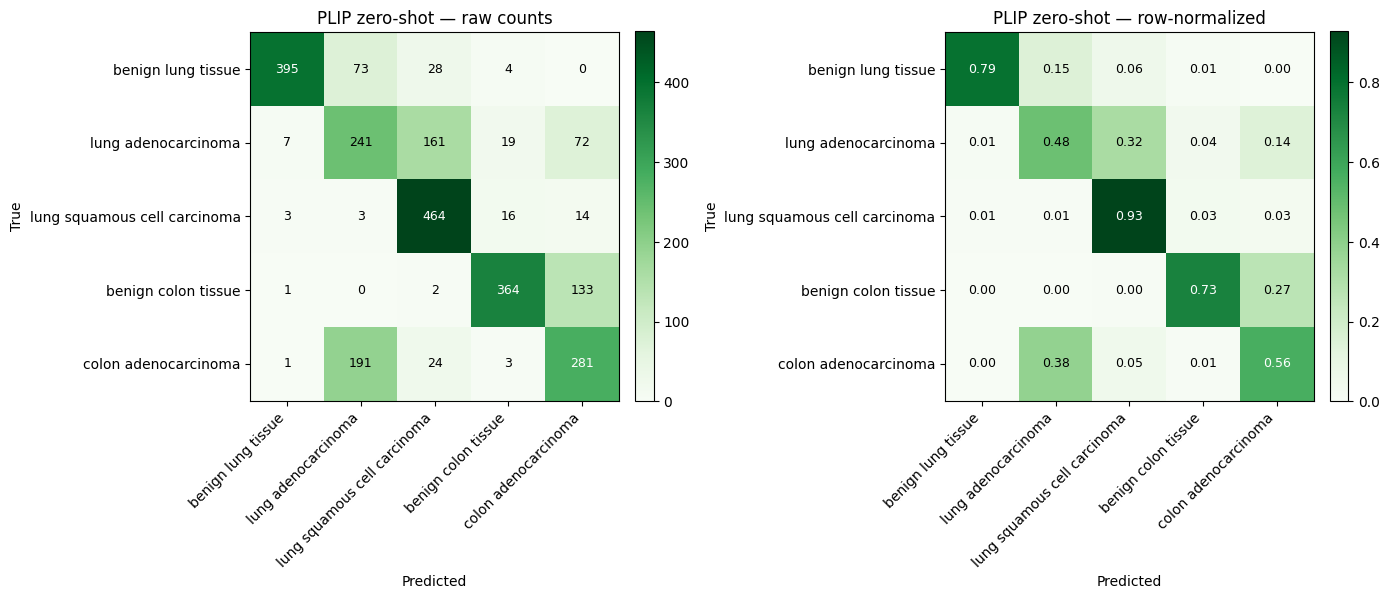

Saved -> /content/histopathology-clip-lab/results/confusion_matrices/plip_zeroshot_confusion_matrices.png


In [14]:
# --- Cell 13: confusion matrices ---
cm_raw = confusion_matrix(
    true_class_ids, predicted_class_ids, labels=list(range(NUM_CLASSES))
)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm_raw, row_sums, where=row_sums > 0,
    out=np.zeros_like(cm_raw, dtype=np.float64),
)

display_labels = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, matrix, title, fmt in [
    (axes[0], cm_raw,  "PLIP zero-shot — raw counts",     "d"),
    (axes[1], cm_norm, "PLIP zero-shot — row-normalized", ".2f"),
]:
    im = ax.imshow(matrix, cmap="Greens")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(display_labels, rotation=45, ha="right")
    ax.set_yticklabels(display_labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = matrix[i, j]
            ax.text(
                j, i, format(val, fmt),
                ha="center", va="center",
                color="white" if val > matrix.max() * 0.6 else "black",
                fontsize=9,
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

cm_plot_path = CM_DIR / f"{VERSION}_confusion_matrices.png"
fig.savefig(cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()

np.save(CM_DIR / f"{VERSION}_cm_raw.npy", cm_raw)
np.save(CM_DIR / f"{VERSION}_cm_norm.npy", cm_norm)
print(f"Saved -> {cm_plot_path}")

## 9 — Shared UMAP (image embeddings + class prompts)

Image embeddings and the five class-prompt embeddings are fitted to a
single UMAP so the reader can see whether each class's image cluster orbits
its own prompt in the shared space. Class prompts are rendered as large
star markers in the matching color.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


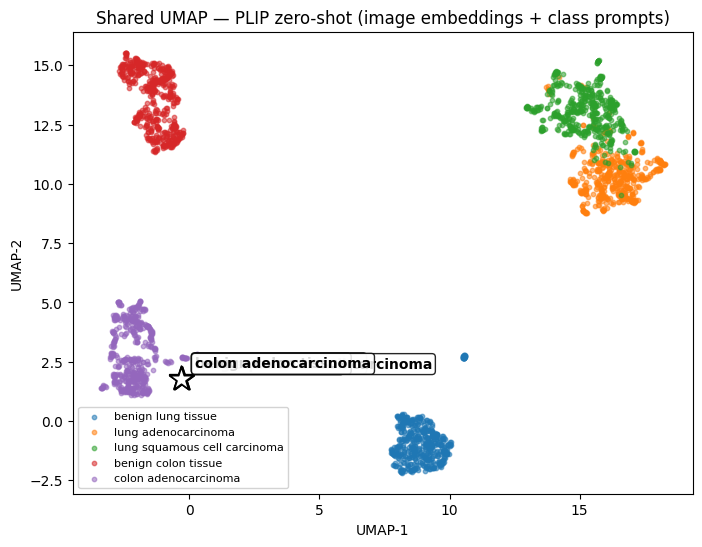

Saved -> /content/histopathology-clip-lab/results/plots/plip_zeroshot_umap.png


In [15]:
# --- Cell 14a: shared UMAP fit (PLIP image embeddings || class prompts) ---
image_2d, text_2d = fit_shared_umap(
    test_image_embeddings, class_text_embeddings_np,
    n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED,
)

class_names = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]

fig = plot_umap_scatter(
    image_2d=image_2d, image_labels=true_class_ids,
    text_2d=text_2d, class_names=class_names,
    title="Shared UMAP — PLIP zero-shot (image embeddings + class prompts)",
)
umap_path = PLOTS_DIR / f"{VERSION}_umap.png"
fig.savefig(umap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_path}")

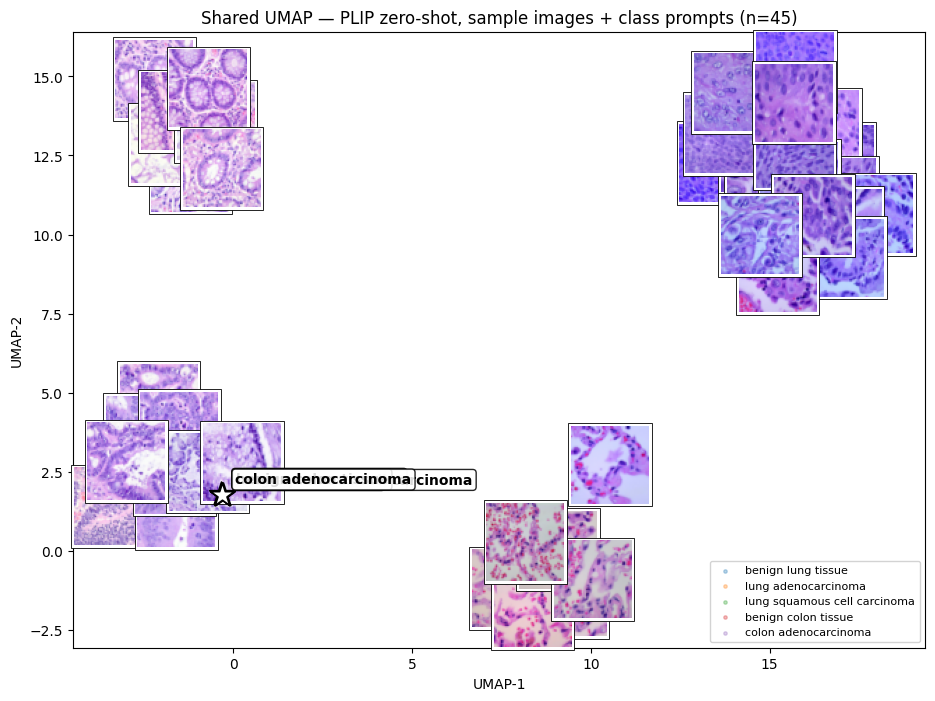

Saved -> /content/histopathology-clip-lab/results/plots/plip_zeroshot_umap_thumbnails.png


In [16]:
# --- Cell 14b: thumbnail UMAP (tutor-style) with prompts on top ---
fig = plot_umap_thumbnails(
    image_2d=image_2d, image_paths=list(test_paths), image_labels=true_class_ids,
    text_2d=text_2d, class_names=class_names,
    max_thumbs=50, thumb_size=(56, 56), min_dist_frac=0.05, seed=SEED,
    title="Shared UMAP — PLIP zero-shot, sample images + class prompts",
)
umap_thumbs_path = PLOTS_DIR / f"{VERSION}_umap_thumbnails.png"
fig.savefig(umap_thumbs_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_thumbs_path}")

## 10 — Centroid-to-prompt similarity heatmap

For each true class, the mean image embedding (centroid) is compared to all
five class-prompt embeddings. A diagonal-heavy matrix indicates each
class's images align most strongly with their own prompt.

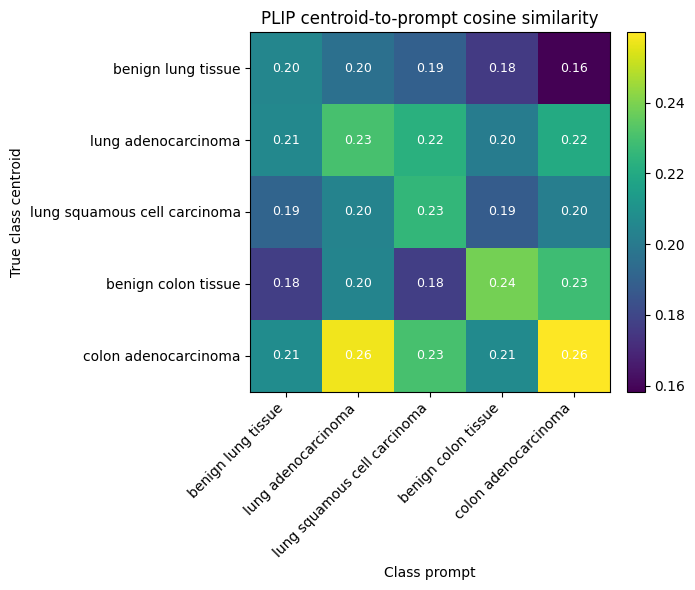

Saved -> /content/histopathology-clip-lab/results/plots/plip_zeroshot_class_similarity.png


In [17]:
# --- Cell 15: centroid-to-prompt similarity heatmap ---
class_centroid_embeddings = np.stack([
    test_image_embeddings[true_class_ids == i].mean(axis=0)
    for i in range(NUM_CLASSES)
])
class_centroid_embeddings /= np.linalg.norm(
    class_centroid_embeddings, axis=1, keepdims=True
)
similarity_heatmap = class_centroid_embeddings @ class_text_embeddings_np.T

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(similarity_heatmap, cmap="viridis")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(display_labels, rotation=45, ha="right")
ax.set_yticklabels(display_labels)
ax.set_xlabel("Class prompt")
ax.set_ylabel("True class centroid")
ax.set_title("PLIP centroid-to-prompt cosine similarity")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(
            j, i, f"{similarity_heatmap[i, j]:.2f}",
            ha="center", va="center",
            color="white" if similarity_heatmap[i, j] < 0.5 else "black",
            fontsize=9,
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

sim_path = PLOTS_DIR / f"{VERSION}_class_similarity.png"
fig.savefig(sim_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {sim_path}")

## 11 — Class-level retrieval (same framing caveat as the baseline)

Image-to-text and text-to-image retrieval against the five shared class
prompts. Positives are defined as samples of the same class; the per-sample
retrieval reported by the original CLIP paper does not apply because
LC25000 has no per-image captions.

In [18]:
# --- Cell 16: image -> class-prompt retrieval ---
i2t_similarity = test_image_embeddings @ class_text_embeddings_np.T
i2t_top_k = np.argsort(-i2t_similarity, axis=1)
i2t_correct_at_rank = (i2t_top_k == true_class_ids[:, None])
i2t_correct_rank = i2t_correct_at_rank.argmax(axis=1)

i2t_recall_at_1 = float((i2t_correct_rank < 1).mean())
i2t_recall_at_5 = float((i2t_correct_rank < 5).mean())  # trivially 1.0 (only 5 classes)
print(f"I→T R@1 (image to class prompt): {i2t_recall_at_1:.4f}")
print(f"I→T R@5 (image to class prompt): {i2t_recall_at_5:.4f}")

I→T R@1 (image to class prompt): 0.6980
I→T R@5 (image to class prompt): 1.0000


In [19]:
# --- Cell 17: class-prompt -> image retrieval ---
t2i_similarity = class_text_embeddings_np @ test_image_embeddings.T
ranked_indices = np.argsort(-t2i_similarity, axis=1)

t2i_recall = {}
for k in RECALL_K:
    hits_at_k = []
    for class_id in range(NUM_CLASSES):
        topk_indices = ranked_indices[class_id, :k]
        positives = (true_class_ids[topk_indices] == class_id).sum()
        hits_at_k.append(float(positives) / k)
    t2i_recall[f"precision_at_{k}"] = float(np.mean(hits_at_k))

print("T→I class-level retrieval (precision@K averaged over classes):")
for k, v in t2i_recall.items():
    print(f"  {k}: {v:.4f}")

T→I class-level retrieval (precision@K averaged over classes):
  precision_at_1: 0.4000
  precision_at_5: 0.5200
  precision_at_10: 0.5200
  precision_at_50: 0.5320


In [20]:
# --- Cell 18: persist retrieval metrics ---
retrieval_path = METRICS_DIR / f"{VERSION}_class_retrieval.json"
retrieval_path.write_text(json.dumps({
    "experiment": EXPERIMENT,
    "version": VERSION,
    "model": PLIP_MODEL_NAME,
    "seed": SEED,
    "note": (
        "Class-level retrieval, NOT CLIP-paper image-text retrieval. "
        "Positives are class-shared; per-sample positives do not exist in LC25000."
    ),
    "image_to_text": {
        "recall_at_1": i2t_recall_at_1,
        "recall_at_5": i2t_recall_at_5,
    },
    "text_to_image": t2i_recall,
}, indent=2))
print(f"Saved -> {retrieval_path}")

Saved -> /content/histopathology-clip-lab/results/metrics/plip_zeroshot_class_retrieval.json


## 12 — Summary: PLIP zero-shot vs the baseline

Side-by-side numbers so the contribution of pathology pretraining is
visible at a glance. The delta is the headline finding for this experiment.

In [21]:
# --- Cell 19: PLIP zero-shot vs baseline ---
BASELINE = {
    "accuracy":          0.6300,
    "balanced_accuracy": 0.6300,
    "macro_f1":          0.6247,
    "weighted_f1":       0.6247,
}

print("=" * 70)
print("PLIP zero-shot vs baseline (frozen ResNet50 + frozen BERT, CLIP-trained)")
print("=" * 70)
print(f"{'metric':>20}  {'PLIP':>10}  {'the baseline':>10}  {'Δ (PLIP - the baseline)':>14}")
print("-" * 70)
for k in ("accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"):
    plip_v = global_metrics[k]
    baseline_v   = BASELINE[k]
    print(f"{k:>20}  {plip_v:>10.4f}  {baseline_v:>10.4f}  {plip_v - baseline_v:>+14.4f}")
print()
print("Interpretation: the Δ column quantifies the contribution of pathology-")
print("specific pretraining to the CLIP paradigm, holding architecture, prompt,")
print("split and evaluation protocol identical.")

PLIP zero-shot vs baseline (frozen ResNet50 + frozen BERT, CLIP-trained)
              metric        PLIP  the baseline  Δ (PLIP - the baseline)
----------------------------------------------------------------------
            accuracy      0.6980      0.6300         +0.0680
   balanced_accuracy      0.6980      0.6300         +0.0680
            macro_f1      0.7004      0.6247         +0.0757
         weighted_f1      0.7004      0.6247         +0.0757

Interpretation: the Δ column quantifies the contribution of pathology-
specific pretraining to the CLIP paradigm, holding architecture, prompt,
split and evaluation protocol identical.
